# TensorBinding.jl — Getting Started

Minimal 1D walk-through of the core API:

1. **1D chain** — `get_bands`, `get_ldos_spatial`, `get_dos_stochastic`
2. **`add_onsite!`** — on-site potential
3. **`add_hopping!`** — generic (NNN) hopping
4. **`add_zeeman!`** — spin + Zeeman field
5. **`add_soc!`** — Rashba spin-orbit coupling
6. **`add_superconductivity!`** — s-wave BdG (Nambu doubling)
7. **`get_scf`** - simple scf calculation

Each section builds on a `L=6` chain (`N=64` sites) and shows bands, spatial
LDOS, and DoS in a single 1x3 figure. No auxiliary-index projections are applied;
see `aux_ldos_examples.ipynb` and `momentum_spectral_functions.ipynb` for
spin/Nambu/sublattice-resolved spectra.

In [3]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../src/TensorBinding.jl")
using .TensorBinding

In [4]:
# Shared 1x3 helper: band structure | spatial LDOS | stochastic DoS
function three_panel(H, omega_phys; Ncheb=100, mdim=60, title_prefix="")
    num_x = H.N
    Ak = TensorBinding.get_bands(H, Ncheb, 1, omega_phys; maxdim=mdim, num_x)
    p1 = heatmap(1:size(Ak,2), collect(omega_phys), Ak;
                 xlabel="k index", ylabel="energy", title=title_prefix*" bands",
                 colorbar=false, c=:thermal)
    ldos = TensorBinding.get_ldos_spatial(H, Ncheb, collect(omega_phys);
               num_x=num_x, mode=:mpo, maxdim=mdim, verbose=false)
    p2 = heatmap(1:num_x, collect(omega_phys), ldos;
                 xlabel="position", ylabel="energy", title=title_prefix*" LDOS(x,omega)",
                 colorbar=false, c=:viridis)

    dos = TensorBinding.get_dos_stochastic(H, Ncheb, collect(omega_phys);
              N_sample=20, maxdim=mdim, verbose=false)
    p3 = plot(collect(omega_phys), dos;
              xlabel="energy", ylabel="DoS", title=title_prefix*" DoS",
              legend=false, lw=2)

    plot(p1, p2, p3; layout=(1,3), size=(900,280), margin=3Plots.mm)
end

three_panel (generic function with 1 method)

---
## 1. 1D nearest-neighbour chain

`L=6` qubits encodes `N=64` sites.  Spectral bounds are estimated automatically
via DMRG when `scale=0` (the default).

**`get_ldos_spatial`** returns an `(N_omega x N_x)` matrix of site-resolved LDOS
via a single online MPO Chebyshev pass — no per-site loop required.

**`get_dos_stochastic`** estimates the total DoS by averaging LDoS over random
Hilbert-space samples.  For a translationally invariant chain the LDoS at any
single site is already a good approximation to the DoS.

In [5]:
L  = 6
H0 = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L)
println(H0)

TBHamiltonian | L=6, N=64, scale=2.5, maxlinkdim=3 | geometry: 64 sites, 1D | no Tn cache


In [6]:
Ncheb = 100
mdim  = 60
omega = range(-4.0, 4.0; length=120)

TensorBinding.KPM_Tn(H0, Ncheb; maxdim=mdim, cutoff=1e-5)

(MPO[MPO
[1] ((dim=2|id=880|"Qubit,Site,n=1")', (dim=2|id=880|"Qubit,Site,n=1"), (dim=1|id=518|"Link,l=1"))
[2] ((dim=2|id=901|"Qubit,Site,n=2")', (dim=2|id=901|"Qubit,Site,n=2"), (dim=1|id=308|"Link,l=2"), (dim=1|id=518|"Link,l=1"))
[3] ((dim=2|id=196|"Qubit,Site,n=3")', (dim=2|id=196|"Qubit,Site,n=3"), (dim=1|id=981|"Link,l=3"), (dim=1|id=308|"Link,l=2"))
[4] ((dim=2|id=679|"Qubit,Site,n=4")', (dim=2|id=679|"Qubit,Site,n=4"), (dim=1|id=796|"Link,l=4"), (dim=1|id=981|"Link,l=3"))
[5] ((dim=2|id=730|"Qubit,Site,n=5")', (dim=2|id=730|"Qubit,Site,n=5"), (dim=1|id=894|"Link,l=5"), (dim=1|id=796|"Link,l=4"))
[6] ((dim=2|id=167|"Qubit,Site,n=6")', (dim=2|id=167|"Qubit,Site,n=6"), (dim=1|id=894|"Link,l=5"))
, MPO
[1] ((dim=2|id=880|"Qubit,Site,n=1")', (dim=2|id=880|"Qubit,Site,n=1"), (dim=3|id=824|"Link,l1"))
[2] ((dim=2|id=901|"Qubit,Site,n=2")', (dim=2|id=901|"Qubit,Site,n=2"), (dim=3|id=684|"Link,l2"), (dim=3|id=824|"Link,l1"))
[3] ((dim=2|id=196|"Qubit,Site,n=3")', (dim=2|id=196|"Qubit,S

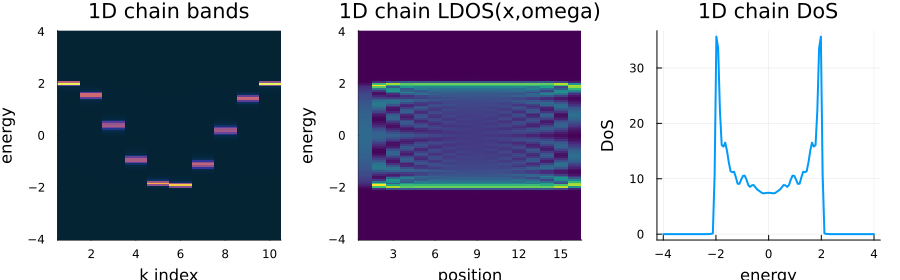

In [7]:
three_panel(H0, omega; Ncheb=Ncheb, mdim=mdim, title_prefix="1D chain")

---
## 2. `add_onsite!` — on-site potential

`add_onsite!(H, f)` adds a diagonal term $V_i = f(i)$ (1-indexed) via a 1D QTCI-compressed
diagonal MPO.  All Chebyshev caches are automatically invalidated.

Here: linear tilt $V(i) = U_0(i/N - 0.5)$ breaks particle-hole symmetry.

In [ ]:
H_on = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L)
U0   = 3.0


TensorBinding.add_onsite!(H_on, i -> U0 * (i / H_on.N - 0.5))

TensorBinding.KPM_Tn(H_on, Ncheb; maxdim=mdim)
three_panel(H_on, omega; Ncheb=Ncheb, mdim=mdim, title_prefix="+ onsite tilt")

---
## 3. `add_hopping!` — generic (NNN) hopping

`add_hopping!(H, f)` compresses the full `N x N` matrix `f(i,j)` into an MPO via QTCI
and adds it to `H`.  Works for any range and any site-dependence.

Here: second-nearest-neighbour hopping $t_2$, dispersion
$\varepsilon(k) = -2t_1\cos k - 2t_2\cos 2k$.

In [ ]:
H_nnn = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L)
t2    = 0.4
TensorBinding.add_hopping!(H_nnn, (i, j) -> abs(i - j) == 2 ? -t2 : 0.0;
                            type=Float64)

omega_nnn = range(-6.0, 6.0; length=120)
TensorBinding.KPM_Tn(H_nnn, Ncheb; maxdim=mdim)
three_panel(H_nnn, omega_nnn; Ncheb=Ncheb, mdim=mdim, title_prefix="+ NNN t2=$(t2)")

---
## 4. `add_zeeman!` — spin-1/2 + Zeeman field

`add_zeeman!(H, h; direction=:z)` automatically prepends a spin-1/2 index
(calling `add_spin!` internally) and adds $h S_z$.  The site chain becomes
`[spin_s, pos_qubits...]` and the physical Hilbert space doubles.

The Zeeman field lifts the spin degeneracy, splitting every band into two branches
separated by $h$.

In [ ]:
H_z = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L)
h_z = 1.5
TensorBinding.add_zeeman!(H_z, h_z; direction=:z)

omega_z = range(-5.0, 5.0; length=120)
TensorBinding.KPM_Tn(H_z, Ncheb; maxdim=mdim)
three_panel(H_z, omega_z; Ncheb=Ncheb, mdim=mdim, title_prefix="+ Zeeman h=$(h_z)")

---
## 5. `add_soc!` — Rashba spin-orbit coupling

`add_soc!(H, lambda; type=:rashba)` adds the 1D Rashba term
$\lambda(S_y K_+ - S_y K_-)$ where $K_\pm$ are shift MPOs.
Combined with the Zeeman field, this opens a gap at the band crossing
and produces a spin-helical state.

In [ ]:
H_soc = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L)
TensorBinding.add_zeeman!(H_soc, 1.0; direction=:z)
TensorBinding.add_soc!(H_soc, 0.5; type=:rashba)

omega_soc = range(-5.0, 5.0; length=120)
TensorBinding.KPM_Tn(H_soc, Ncheb; maxdim=mdim)
three_panel(H_soc, omega_soc; Ncheb=Ncheb, mdim=mdim, title_prefix="+ Zeeman + Rashba")

---
## 6. `add_superconductivity!` — spinless s-wave BdG

`add_superconductivity!(H, Delta; type=:swave)` extends `H` to Nambu space:

$$H_{\rm BdG} = \tau_z \otimes H + \tau_+ \Delta + \tau_- \Delta^\dagger$$

The spectrum has exact particle-hole symmetry ($\pm E$ pairs).
A superconducting gap of size $\sim 2|\Delta|$ opens at $\omega = 0$.

Info: on-site (s-wave) pairing is forbidden for spinless fermions (Δ(i,i) = 0 by Fermi antisymmetry).  Constructing nearest-neighbour p-wave instead.
KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -1.9978,  E_max = 1.9932
  center = -0.0023,  scale = 2.195
Info: H.nambu_s detected; auto-enabling nambu_proj=true (pass proj_nambu=1/2 to select particle/hole sector).
Info: H.nambu_s detected; auto-enabling nambu_proj=true (pass proj_nambu=1/2 to select particle/hole sector).


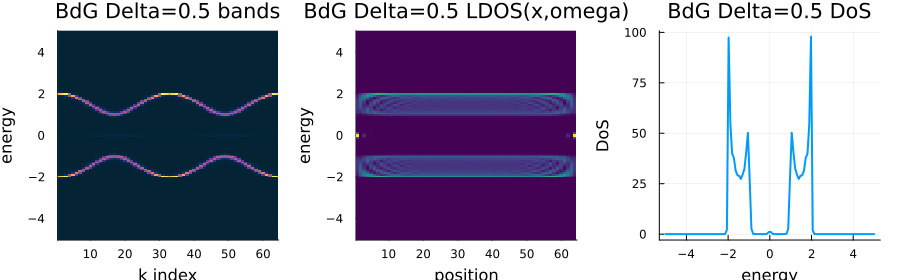

In [30]:
H_sc  = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L)
Delta = 0.5
TensorBinding.add_superconductivity!(H_sc, Delta; type=:swave)

omega_sc = range(-5.0, 5.0; length=120)
TensorBinding.KPM_Tn(H_sc, Ncheb; maxdim=mdim)
three_panel(H_sc, omega_sc; Ncheb=Ncheb, mdim=mdim, title_prefix="BdG Delta=$(Delta)")